<a href="https://colab.research.google.com/github/HashmatHashmi/Corsera-test/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports & Config

In [82]:
import cv2
import os
import numpy as np
from tqdm import tqdm

IMG_SIZE = 224

### Image Preprocessing Function (DIP CORE)

In [83]:
def load_images(folder_path, classes):
    X = []
    y = []

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)

        for img_name in tqdm(os.listdir(class_path), desc=f"Loading {class_name}"):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Noise removal
            img = cv2.GaussianBlur(img, (5, 5), 0)

            # Normalize
            img = img / 255.0

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)


### Load Training & Testing Data

In [84]:
classes = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor', 'no_tumor']

# Update paths to point to the dataset in Google Drive
X_train, y_train = load_images("/content/drive/MyDrive/Colab Notebooks/Brain_Tumor_Detection_Project/Training", classes)
X_test, y_test = load_images("/content/drive/MyDrive/Colab Notebooks/Brain_Tumor_Detection_Project/Testing", classes)

# Reshape for CNN
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Loading no_tumor: 100%|██████████| 105/105 [00:01<00:00, 94.54it/s] 


Training shape: (2870, 224, 224, 1)
Testing shape: (394, 224, 224, 1)


In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### CNN Model (MULTI-CLASS)

In [86]:
def build_model():
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(4, activation='softmax'))  # 4 classes

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


### Train Model

In [ ]:
model = build_model()

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.4922 - loss: 1.1342 - val_accuracy: 0.4112 - val_loss: 2.2200
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7317 - loss: 0.6319 - val_accuracy: 0.5279 - val_loss: 2.3201
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.8390 - loss: 0.4267 - val_accuracy: 0.6117 - val_loss: 1.9144
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8831 - loss: 0.3002 - val_accuracy: 0.6371 - val_loss: 2.2666
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.9124 - loss: 0.2301 - val_accuracy: 0.7056 - val_loss: 2.9773
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9274 - loss: 0.1820 - val_accuracy: 0.7234 - val_loss: 3.4851
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.9427 - loss: 0.1482 - val_accuracy: 0.7132 - val_loss: 3.8756
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9470 - loss: 0.1365 - val_accu

### Save Model

In [87]:
model.save("brain_tumor_multiclass_model.h5")
print("✅ Model saved successfully")

✅ Model saved successfully


### Load Model

In [100]:
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_multiclass_model.h5")
classes = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor', 'no_tumor']
IMG_SIZE = 224


### Prediction Function

In [101]:
def predict_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    print("🧠 Prediction:", classes[class_index])


### Test Image

In [102]:
predict_image("/content/drive/MyDrive/Colab Notebooks/Brain_Tumor_Detection_Project/Testing/glioma_tumor/image(12).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
🧠 Prediction: pituitary_tumor


In [103]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])


Train Accuracy: 0.9703832864761353
Validation Accuracy: 0.7614213228225708


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 839ms/step


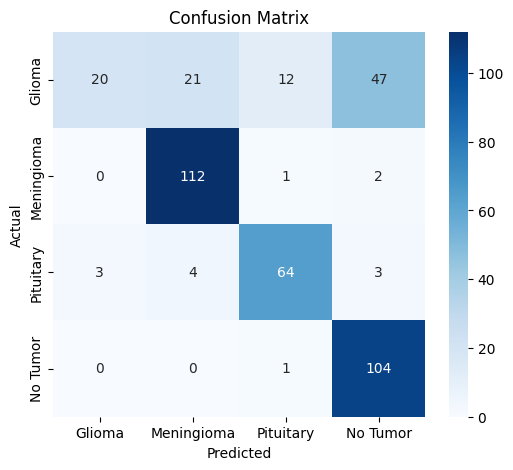

In [104]:
# Predict classes for test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Converts probabilities to class indices

# If y_test is already like [0,1,2,3,...], just use it directly
y_true = y_test

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [105]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))


              precision    recall  f1-score   support

      Glioma       0.87      0.20      0.33       100
  Meningioma       0.82      0.97      0.89       115
   Pituitary       0.82      0.86      0.84        74
    No Tumor       0.67      0.99      0.80       105

    accuracy                           0.76       394
   macro avg       0.79      0.76      0.71       394
weighted avg       0.79      0.76      0.71       394



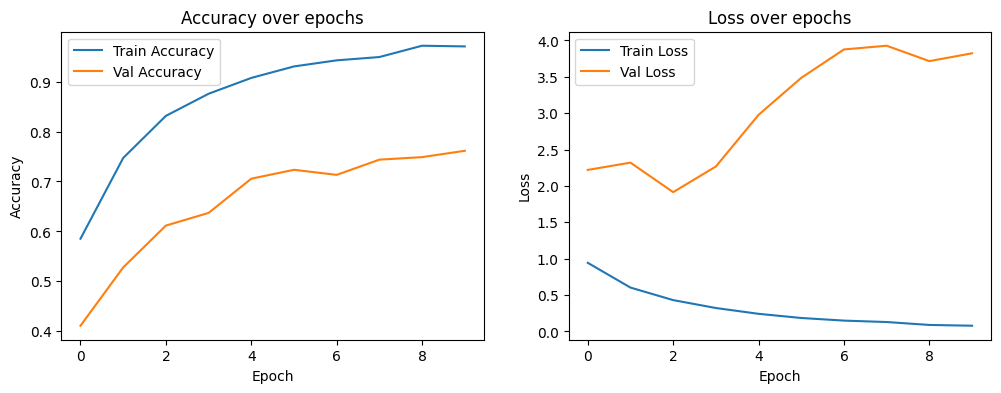

In [106]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


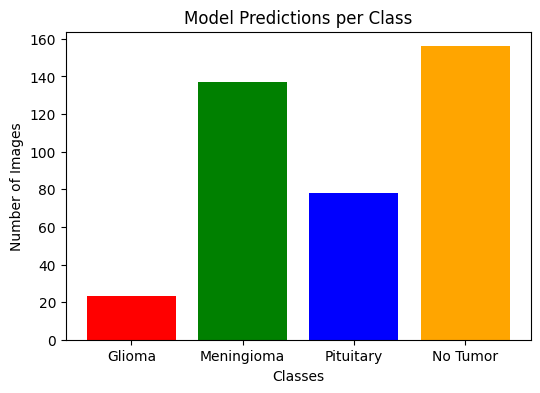

In [107]:
import matplotlib.pyplot as plt

# Count predictions per class
unique, counts = np.unique(y_pred_classes, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar([class_names[i] for i in unique], counts, color=['red', 'green', 'blue', 'orange'])
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Model Predictions per Class')
plt.show()
